# __Métodos Baseados em Distância__
<font size=3>

Os **métodos baseados em distância** utilizam medidas de *similaridade* ou *dissimilaridade* entre amostras do _dataset_ para realizar tarefas como _classificação_ e _regressão_ (em aprendizado supervisionado), além de _agrupamento_ e _detecção de anomalias_ (em aprendizado não supervisionado). A simplicidade e interpretabilidade desses métodos garantem muitas aplicações, mas é necessário cautela na escolha de métricas adequadas e nos desafios em lidar com dados de altas dimensões.

A seguir, vamos analizar a distribuição das amostras de **flores de iris** em um espaço bidimensional.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
dset = load_iris()

X = dset.data
y = dset.target

species = dset.target_names

print(f"X:{X.shape}, y:{y.shape}\n")

print("Categorias:", set(y))

X:(150, 4), y:(150,)

Categorias: {np.int64(0), np.int64(1), np.int64(2)}


<font size=3>
<br>
    
Iremos **normalizar** e realizar a **análise de componentes principais** em duas dimensões, a fim de representar os **quatro atributos** das amostras em um **plote 2D**.

In [5]:
# normalização:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# redução de dimensionalidade:
pca = PCA(n_components=2)
X_pc = pca.fit_transform(X_norm)

print(f"Componentes principais:", X_pc.shape)

Componentes principais: (150, 2)


In [6]:
explained_variance = pca.explained_variance_ratio_

print(f"Variância explicada pelo Componente 1: {explained_variance[0]*100:.2f}%")
print(f"Variância explicada pelo Componente 2: {explained_variance[1]*100:.2f}%")
print(f"Variância total explicada pelas duas componentes: {sum(explained_variance)*100:.2f}%")

Variância explicada pelo Componente 1: 72.96%
Variância explicada pelo Componente 2: 22.85%
Variância total explicada pelas duas componentes: 95.81%


<font size=3>
<br>

Vamos calcular os **pontos médios** (para cada espécie de flor), com base nas **componentes principais 1** e **2**.

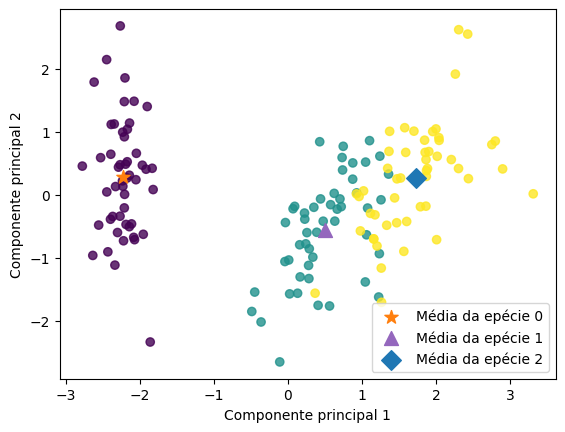

In [7]:
# média das posições de todas as amostras nas coordenadas (PC's):
μ1 = X_pc[y == 0].mean(axis=0)
μ2 = X_pc[y == 1].mean(axis=0)
μ3 = X_pc[y == 2].mean(axis=0)

plt.scatter(X_pc[:, 0], X_pc[:, 1], marker='o', c=y, alpha=0.8)
plt.scatter(*μ1, marker='*', s=100, c="tab:orange", label='Média da epécie 0')
plt.scatter(*μ2, marker='^', s=100, c="tab:purple", label='Média da epécie 1')
plt.scatter(*μ3, marker='D', s=100, c="tab:blue", label='Média da epécie 2')
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

<font size=3>

**Observe** acima que os pontos médios representam bem as classes dos dados. Em uma abordagem simplificada, **poderíamos definir a classe das amostras com base nas suas _distâncias_ dos pontos médios.**

## __1. O algoritmo *1-Nearest Neighbour* (1-NN):__
<font size=3>

O algoritmo do **1º Vizinho Mais Próximo** (*1-Nearest Neighbor* &mdash; 1-NN) é um dos métodos mais simples de **classificação** e **regressão** em aprendizado de máquina baseado em **distância**. Ele pertence à família dos algoritmos **k-NN**, onde $k = 1$. Este algoritmo é considerado *lazy* (preguiçoso) pois não apresenta propriamente fase de treinamento — **não realiza ajustes de parâmetros internos**.

<font size=3>

Em problemas de classificação ou regressão, quando realizamos uma **predição**, com base em uma *nova amostra* de entrada, temos que:
- O algoritmo calcula a **distância** entre essa nova amostra (`X_test`) e **todas as amostras no conjunto de treinamento** (`X_train`);

- A métrica de distância mais comum é a **Euclidiana** &mdash; onde se mede a distância entre dois pontos $\mathbf{x}_i$ e $\mathbf{x}_j$ para $d$ dimensões (número de atributos),
$$
    d(\mathbf{x}_i,\, \mathbf{x}_j) = \sqrt{\sum_{l=1}^d \left(x_i^l - x_j^l\right)^2} \, ,
$$
mas outras como [_Manhattan_](https://en.wikipedia.org/wiki/Taxicab_geometry), [_Minkowski_](https://en.wikipedia.org/wiki/Minkowski_distance) ou [cosseno](https://en.wikipedia.org/wiki/Cosine_similarity) também podem ser usadas;

- Identifica a amostra no conjunto de treinamento **mais próxima** (ou seja, o "1º vizinho mais próximo") da nova amostra;

- Para **classificação**: A nova amostra recebe a **mesma classe** do vizinho mais próximo;

- Para **regressão**: O valor previsto é o **valor alvo** do vizinho mais próximo.

<font size=3><center>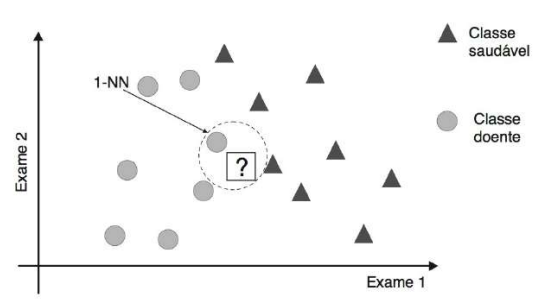</center></p><p style="text-align:center;"><em>Figura 4.2 do livro.</em>

In [8]:
class k1NN:

    def fit(self, X, y):

        '''Armazena os dados de treinamento.'''

        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X_test):

        '''Faz a previsão para cada amostra em X_test.'''

        X_test = np.array(X_test)

        predictions = []

        for x in X_test:

            # Calcula a distância euclidiana:
            distances = np.linalg.norm(self.X_train - x, axis=1)

            # Encontra o índice do vizinho mais próximo:
            nearest_index = np.argmin(distances)

            # Retorna a classe ou valor correspondente:
            predictions.append(self.y_train[nearest_index])

        return np.array(predictions)


In [9]:
# simulando os dados de treinamento e teste:
X_train = [[2, 3], [5, 4], [3, 1], [6, 7]]
y_train = [0, 1, 0, 1] # classes

X_test = [[4, 3]]

# definindo o modelo:
model = k1NN()

# fitando o modelo:
model.fit(X_train, y_train)

# fazendo previsões:
y_pred = model.predict(X_test)

print(f"Classe prevista para {X_test}: {y_pred}")

Classe prevista para [[4, 3]]: [1]


<font size=3>
<br>

A simplicidade desse algoritmo pode garantir boas predições, mas pode apresentar problemas como **sensibilidade a ruídos**, alto **custo computacional** em grandes conjuntos, e tendência a **overfitting**. É recomendado para **dados pequenos** ou de **baixa dimensionalidade**.

Agora, vamos considerar o **_dataset_ de íris**.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

<font size=3>

O desempenho de métodos baseados em distância, como o **1-NN**, é diretamente influenciado pela **função de distância** escolhida e pela **escala dos atributos**, já que diferenças de magnitude (_e.g._ cm _vs_ km) podem distorcer o cálculo. Para evitar esse problema, é comum **normalizar os atributos**, garantindo que todos tenham _pesos equivalentes_ na medição de distâncias.  

In [11]:
# dividindo os dados:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=7)

# normalização:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [12]:
# fitando o modelo:
model.fit(X_train, y_train)

# fazendo previsões:
y_pred = model.predict(X_test)

print("Predições:        ", y_pred, "\n")
print("Dados verdadeiros:", y_test)

Predições:         [2 1 0 1 1 0 1 1 0 1 1 1 0 2 0 2 2 2 0 0 1 2 1 1 2 2 1 1 2 2 2 1 0 2 1 0 0
 0 0 2 2 1 2 2 1] 

Dados verdadeiros: [2 1 0 1 2 0 1 1 0 1 1 1 0 2 0 1 2 2 0 0 1 2 1 2 2 2 1 1 2 2 2 1 0 2 1 0 0
 0 0 2 2 1 2 2 1]


In [13]:
# medindo a performance:
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.2f}")

Acurácia: 0.93


## __2. O algoritmo *k-Nearest Neighbour* (k-NN):__
<font size=3>

Para generalizar, vamos agora considerar os **$k$ vizinhos mais próximos** (os $k$ pontos de treinamento com as menores distâncias). Para tarefas de
- **classificação**, a classe predominante entre os $k$ vizinhos é atribuída à nova amostra (votação majoritária — **moda**);  
- já para **regressão**, o valor previsto é a **média** (ou média ponderada) dos valores dos $k$ vizinhos.

<font size=3><center>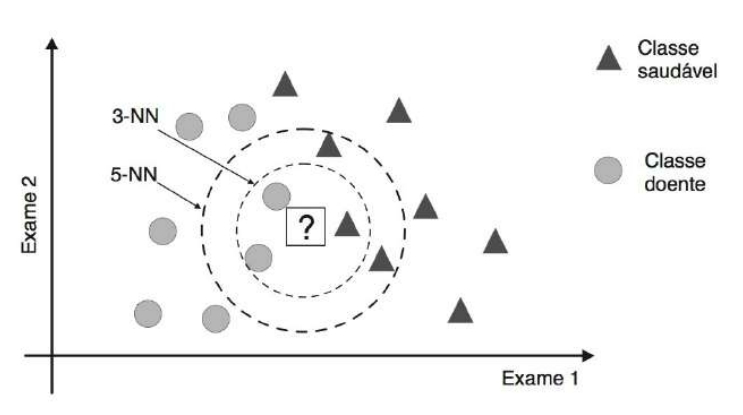</center></p><p style="text-align:center;"><em>Figura 4.4 do livro.</em>

<font size=3>
    
> **Observação:** na **escolha do $k$**, valores **pequenos** (_e.g._, 1) tornam o modelo sensível a ruídos (_overfitting_). Por outro lado, valores **grandes** de $k$ suavizam a decisão, mas pode perder detalhes importantes (_underfitting_).  

In [14]:
from collections import Counter

class kNN:

    def __init__(self, k=3):

        '''Define o número de vizinhos a serem considerados.'''

        self.k = k


    def fit(self, X, y):

        '''Armazena os dados de treinamento.'''

        self.X_train = np.array(X)
        self.y_train = np.array(y)


    def predict(self, X_test):

        '''Faz a previsão para cada amostra em X-test.'''

        X_test = np.array(X_test)
        predictions = []

        for x in X_test:

            # Calcula a distância euclidiana para todos os pontos de treino:
            distances = np.linalg.norm(self.X_train - x, axis=1)

            # Encontra os índices dos k vizinhos mais próximos:
            k_indices = np.argsort(distances)[:self.k]

            # Obtém as classes desses vizinhos:
            k_neighbors_labels = self.y_train[k_indices]

            # Determina a classe mais comum (maioria):
            most_common = Counter(k_neighbors_labels).most_common(1)[0][0]

            predictions.append(most_common)

        return np.array(predictions)


In [15]:
# definindo o modelo com k = 2:
model = kNN(k=3)

# fitando o modelo:
model.fit(X_train, y_train)

# fazendo previsões:
y_pred = model.predict(X_test)

print("Predições:        ", y_pred, "\n")
print("Dados verdadeiros:", y_test)

Predições:         [2 1 0 1 1 1 1 1 0 1 1 1 0 2 0 1 2 2 0 0 1 2 1 1 2 1 1 1 2 2 2 1 0 2 1 0 0
 0 0 2 2 1 2 2 1] 

Dados verdadeiros: [2 1 0 1 2 0 1 1 0 1 1 1 0 2 0 1 2 2 0 0 1 2 1 2 2 2 1 1 2 2 2 1 0 2 1 0 0
 0 0 2 2 1 2 2 1]


In [16]:
# medindo a performance:
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.2f}")

Acurácia: 0.91


### __2.1 Usando a biblioteca *scikit learn*:__

In [17]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# definindo o modelo:
model = KNeighborsClassifier(n_neighbors=3)

# fitando o modelo:
model.fit(X_train, y_train)

# predição e avaliação:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.2f}")

Acurácia: 0.91


### __2.2 Superfície de decisão:__
<font size=3>

As **superfícies de decisão** são as fronteiras que separam diferentes classes no espaço de dados. No caso do **1-NN**, essas superfícies podem ser altamente irregulares, pois cada ponto dos dados de "treinamento" influencia diretamente a classificação do espaço ao seu redor. O [diagrama de Voronoi](https://en.wikipedia.org/wiki/Voronoi_diagram) divide o espaço em regiões associadas a cada ponto do conjunto de treinamento. Cada região contém todos os pontos que têm aquele ponto de treino como o mais próximo.


<font size=3><center>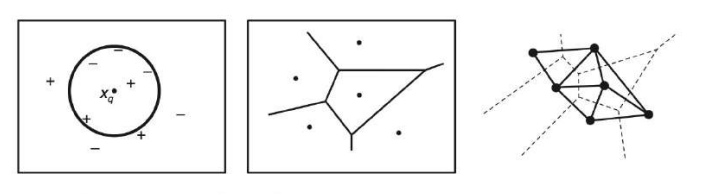</center></p><p style="text-align:center;"><em>Figura 4.3 do livro.</em>

In [19]:
from matplotlib.colors import ListedColormap

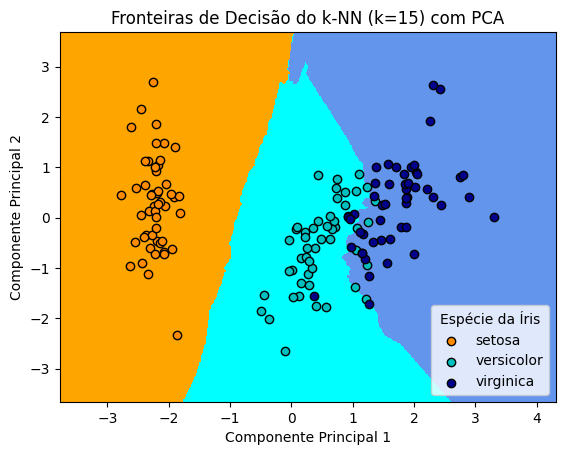

In [20]:
# definindo o modelo:
k = 15
model = KNeighborsClassifier(n_neighbors=k)

# fitando o modelo com as componentes principais:
model.fit(X_pc, y)

# determinando os limites do gráfico a partir dos dados transformados:
x_min, x_max = X_pc[:, 0].min() - 1, X_pc[:, 0].max() + 1
y_min, y_max = X_pc[:, 1].min() - 1, X_pc[:, 1].max() + 1

# criando a grade de pontos:
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# realizando a predição de cada ponto da grade:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plote da superfície de decisão:
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ['darkorange', 'c', 'darkblue']

plt.title(f"Fronteiras de Decisão do k-NN (k={k}) com PCA")

plt.contourf(xx, yy, Z, cmap=cmap_light)

for i, target_name in enumerate(species):
    plt.scatter(X_pc[y==i, 0], X_pc[y==i, 1], color=cmap_bold[i], edgecolor="black", label=target_name)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Espécie da Íris")
plt.show()

### __2.2 Melhor valor de $k$:__
<font size=3>

Podemos encontrar o melhor valor de $k$ fazendo uma varredura de um intervalo de valores e medindo as respectivas performances. O valor de $k$ escolhido será aquele de performance ótima.

In [21]:
# Intervalo de valores de k:
k_values = range(1, 21)

metric_values = []

for k in k_values:

    # fazendo a predição para cada valor de k:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    # medindo a perdormance com os dados de teste:
    metric_values.append(accuracy_score(y_test, y_pred))



Melhor valor de k é 7, com acurácia = 0.96.


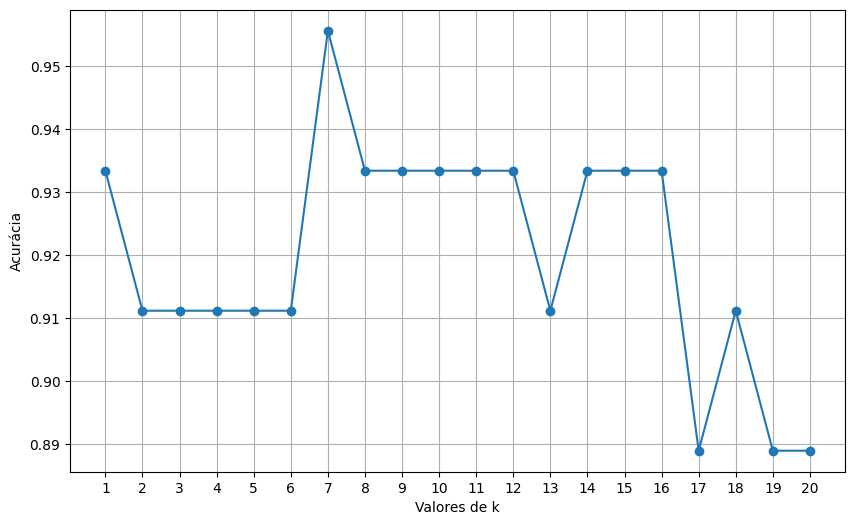

In [22]:
import matplotlib.pyplot as plt

# O melhor valor de k é dado pelo valor mínimo da lista da métrica:
best_k = k_values[np.argmax(metric_values)]

print(f"\nMelhor valor de k é {best_k}, com acurácia = {max(metric_values):.2f}.")

plt.figure(figsize=(10, 6))
plt.plot(k_values, metric_values, marker='o')
plt.xticks(k_values)
plt.xlabel('Valores de k')
plt.ylabel('Acurácia')
plt.grid()
plt.show()

## __Referências:__
<font size=3>

- **(4.1 - 4.6)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
  